# BTC CTA Strategy: Momentum × Funding Rate × Order-Flow Tri-Signal

## Strategy Thesis

Three alpha sources combined in a principled way, each grounded in a distinct mechanism:

| # | Signal | Role | Source | Rationale |
|---|--------|------|--------|-----------|
| 1 | **Multi-Horizon Momentum** | Direction (75%) | Price (local Binance CSV) | BTC trends persistently across macro cycles; exploited via 3M/6M/12M risk-adjusted TSMOM. Longer lookbacks filter out intra-month noise and short-lived mean-reversion. |
| 2 | **Funding Rate** | Size modifier | Binance Perp API (same data as Coinglass) | Used as a **position sizing** input, not a directional bet. Elevated funding (crowded longs) → shrink position size. Negative funding (crowded shorts) → allow slightly larger position. Avoids the trap of fighting a sustained bull trend with a contrarian short. |
| 3 | **Taker Order-Flow Imbalance** | Direction (25%) | Binance kline `taker_buy_base` | 21-day z-score of taker buy ratio captures persistent buying/selling pressure as a trend-confirming signal. |

**Position Sizing:** Volatility targeting at 60% p.a. (appropriate for crypto).  
Compared to a 20% target (equity-typical), a 60% target is needed here because BTC's realised vol (~48% p.a.) would otherwise force positions down to near-zero.  
**Execution assumption:** Signal observed at close `t`, position entered at `t+1` (1-day lag).  
**Transaction Cost:** 5 bps/side.

---

## Strategy Methodology — Plain Language Guide

> This section explains **what the strategy does and why**, without assuming a quant background. Read this before diving into the code.

---

### What Kind of Strategy Is This?

This is a **CTA (Commodity Trading Advisor) trend-following strategy** — a rules-based systematic approach that:

1. Looks at Bitcoin's recent price history and order data
2. Decides whether BTC is currently in an **uptrend** or **downtrend**
3. Takes a **long position** (buys) if it thinks the trend is up, or a **short position** (sells) if down
4. Automatically sizes and adjusts that position every day

There is **no discretion** — no human judgment call on any given day. Every decision follows a fixed formula applied to fresh market data.

---

### The Core Idea: Why Should Trend-Following Work?

BTC (like most assets) tends to **trend persistently** rather than randomly jumping up and down. A price that has been rising for 3–6 months is more likely to still be rising next month than to suddenly reverse — not because of magic, but because:

- Large investors (institutions, funds) buy or sell gradually over months, creating sustained price moves
- News and macro events (halving cycles, regulatory shifts, adoption waves) play out over quarters, not days
- Herding and momentum feedback loops exist in every market

Trend-following exploits this by **riding existing trends** and flipping when they reverse.

---

### The Three Inputs

#### 1. Price Momentum — *"What direction has BTC been trending?"*

We measure how much BTC has risen or fallen over the past **3 months, 6 months, and 12 months**, each normalised by how volatile that period was (so a 20% move in a calm month counts more than a 20% move in a wild month).

- Strong uptrend over all three windows → **strong long signal**
- Downtrend over all three windows → **strong short signal**
- Mixed signals across windows → **weak / neutral signal**

Using *three* lookbacks instead of one avoids the trap of being too sensitive to short-term noise (3-month only) or too slow to react to trend reversals (12-month only). The three are averaged together with equal weight.

#### 2. Taker Order Flow — *"Who is driving the move right now?"*

Every trade on a crypto exchange has two sides: a passive side (limit order sitting in the book) and an aggressive side (market order that crosses the spread to execute immediately). The aggressive side is called a **taker**.

- A high proportion of **taker buys** → buyers are impatient, willing to pay up → strong demand signal
- A high proportion of **taker sells** → sellers are impatient, dumping at market → supply pressure

We take the 21-day z-score of this ratio to ask: *"Is today's buyer aggression unusually high or low compared to the recent baseline?"* This signal acts as a **real-time corroborator** of the momentum signal — if momentum says "uptrend" and order flow says "active buyers", the two agree and we hold the position with more confidence.

#### 3. Funding Rate — *"Is the trade too crowded to hold at full size?"*

Bitcoin perpetual futures (the main instrument used to trade BTC with leverage) have a mechanism called **funding**: every 8 hours, traders on the winning side of a crowded bet pay a fee to traders on the losing side.

- **Positive funding** = more longs than shorts → **longs are paying shorts** → the long trade is crowded
- **Negative funding** = more shorts than longs → **shorts are paying longs** → the short trade is crowded

When a trade is very crowded, it's more fragile — one piece of bad news can trigger a wave of forced liquidations. Instead of using this as a contrarian signal (shorting when funding is high), we use it as a **position size reducer**: *"Keep the trend-following direction, but hold less when you're in a crowded trade."*

This avoids the worst failure mode of contrarian funding strategies: in a sustained bull market, funding can stay elevated for months. A contrarian short during that entire period would bleed continuously.

---

### How It All Combines

```
Step 1 — Direction:    trend_signal = 75% × momentum + 25% × order_flow
Step 2 — Sizing:       position_raw = trend_signal × funding_modifier
Step 3 — Risk control: position = position_raw × (60% target_vol / current_vol)
Step 4 — Execution:    trade next day's open (1-day lag to avoid look-ahead bias)
```

**Plain English version:**
- The strategy decides "how bullish or bearish" it is on a scale of −1 (maximum short) to +1 (maximum long), driven mostly by multi-month momentum
- It then multiplies that conviction by a crowding discount (funding rate modifier) — so "moderately bullish but very crowded" becomes a small position
- Finally, it scales the position so that the **risk taken is constant** across different market volatility regimes: bigger position in calm markets, smaller position in volatile ones

---

### Risk Management: Volatility Targeting

Imagine two scenarios:
- **Calm month**: BTC moves ±1% per day → a 1× long position risks ~1% per day
- **Crash month**: BTC moves ±5% per day → a 1× long position risks ~5% per day

Without adjustment, the strategy takes 5× more risk in the crash month, which can cause a catastrophic drawdown just when markets are already stressed.

**Volatility targeting** solves this by automatically halving the position size when volatility doubles, keeping daily risk exposure approximately constant. We target **60% annualised volatility** (appropriate for BTC — using the equity-market standard of 20% would result in positions near zero, since BTC is naturally 3× more volatile than stocks).

---

### What Does "Backtesting" Tell Us?

After building the strategy rules, we apply them to **historical data we never used to build the rules** and see what would have happened. The key metrics we examine:

| Metric | What it really means |
|--------|---------------------|
| **CAGR +12.1%** | The strategy would have compounded money at 12.1% per year on average |
| **Volatility 17.6%** | The strategy's returns fluctuated by about ±17.6% annualised — much less than BTC's ±56.5% |
| **Sharpe 0.51** | For every unit of risk taken, the strategy earned 0.51 units of excess return. Anything > 0.5 is considered good for a single-asset strategy |
| **Max Drawdown −17.3%** | The worst the strategy ever lost from its previous peak — vs. −76.7% for buy-and-hold BTC |
| **Calmar 0.70** | The annual return divided by the worst loss: 12.1% ÷ 17.3% = 0.70. Higher = better risk efficiency |

The strategy dramatically **reduces drawdowns** (−17% vs −77%) at the cost of giving up some of the explosive upside in strong bull markets. This is the fundamental trade-off of trend-following: smoother ride, less lottery-ticket upside.

---

### Honest Limitations

1. **Single asset**: Trend-following works best diversified across many uncorrelated assets. A single-asset CTA is more volatile than a 20-asset multi-market CTA.
2. **Backtest period (2021–2026)**: Contains exactly one full BTC halving cycle — too short to make strong statistical claims. The results are directionally consistent with academic evidence but not statistically definitive.
3. **Transaction costs are optimistic**: 5 bps assumes small notional and taker fills. Real costs for larger positions are higher.
4. **Momentum lag**: The strategy will always be late at trend turning points. The 2022 top-to-bottom crash is an example — it takes 3+ months of downtrend before the 6M/12M momentum signals flip short.

## 1 · Data Collection

### 1a · Binance Klines Download Pipeline

Downloads hourly BTCUSDT klines (spot) via the public Binance REST API — no API key required.

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| Symbol | BTCUSDT | Spot, highest liquidity |
| Interval | 1h | Resampled to daily downstream |
| Start | 2020-01-01 | 16-month warmup before strategy live date (2021-04-04) needed for 12M momentum lookback |
| Batch size | 1000 | Binance max per request (~41 days of hourly data) |
| Resume | Yes | Re-run anytime to fetch only missing tail |

**Run this cell once (or periodically) before the data loading cell below.**

In [ ]:
import time, requests, pandas as pd
from datetime import datetime, timezone

SYMBOL, INTERVAL, START_DATE = 'BTCUSDT', '1h', '2020-01-01'
DATA_PATH = 'btcusdt_1h.csv'
PROXIES   = None   # e.g. {'https': 'http://127.0.0.1:7890'}

_COLS = ['open_time','open','high','low','close','volume','close_time',
         'quote_vol','n_trades','taker_buy_base','taker_buy_quote','ignore']
_KEEP = ['open_time','open','high','low','close','volume','taker_buy_base']
_URL  = 'https://api.binance.com/api/v3/klines'

def _fetch(ms):
    for n in range(6):
        try:
            r = requests.get(_URL, params={'symbol':SYMBOL,'interval':INTERVAL,
                             'startTime':ms,'limit':1000}, timeout=30, proxies=PROXIES)
            r.raise_for_status(); return r.json()
        except Exception: time.sleep(2**n)
    raise RuntimeError('Binance API failed')

def download_btc_hourly(path=DATA_PATH):
    t0  = int(datetime.strptime(START_DATE,'%Y-%m-%d').replace(tzinfo=timezone.utc).timestamp()*1000)
    now, rows, cur = int(datetime.now(timezone.utc).timestamp()*1000), [], t0
    while cur <= now:
        b = _fetch(cur)
        if not b: break
        rows.extend(b); last = int(b[-1][0])
        print(f'  {len(rows):,} candles  {datetime.fromtimestamp(last/1000,timezone.utc):%Y-%m-%d}', end='\r')
        if len(b) < 1000: break
        cur = last + 3_600_000; time.sleep(0.12)

    df = pd.DataFrame(rows, columns=_COLS)[_KEEP].copy()
    df['open_time'] = pd.to_datetime(df['open_time'], unit='ms', utc=True).dt.tz_localize(None)
    df[_KEEP[1:]] = df[_KEEP[1:]].apply(pd.to_numeric)
    df.to_csv(path, index=False)
    print(f'\nSaved {len(df):,} rows → {path}  [{df["open_time"].iloc[0]:%Y-%m-%d} → {df["open_time"].iloc[-1]:%Y-%m-%d}]')
    return df.set_index('open_time')

raw_h_index = download_btc_hourly()


In [16]:
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mtick
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

# Relative path — resolves to the same directory as this notebook
DATA_PATH = 'btcusdt_1h.csv'

# ── 1a. Price: hourly Binance kline → daily OHLCV + order-flow ───────────────
raw_h = pd.read_csv(DATA_PATH)
raw_h['open_time'] = pd.to_datetime(raw_h['open_time'])
raw_h.set_index('open_time', inplace=True)

daily = raw_h.resample('D').agg(
    open          = ('open',           'first'),
    high          = ('high',           'max'),
    low           = ('low',            'min'),
    close         = ('close',          'last'),
    volume        = ('volume',         'sum'),
    taker_buy_vol = ('taker_buy_base', 'sum'),
).dropna(subset=['close'])

# Taker buy ratio: fraction of total volume initiated by aggressive buyers
daily['taker_buy_ratio'] = daily['taker_buy_vol'] / daily['volume'].replace(0, np.nan)

print(f'Price  : {len(daily)} daily bars  [{daily.index[0].date()} -> {daily.index[-1].date()}]')
daily.tail(3)


Price  : 2244 daily bars  [2020-01-01 -> 2026-02-21]


,open,high,low,close,volume,taker_buy_vol,taker_buy_ratio
open_time,,,,,,,
2026-02-19,66461.00,67320.00,65631.83,67003.73,14542.26988,7106.70741,0.488693
2026-02-20,67003.73,68318.39,66280.20,68020.01,35351.87091,15001.46034,0.424347
2026-02-21,68020.00,68099.54,67676.61,67802.80,1367.75171,730.32152,0.533958


### Data Anatomy — Hourly Klines to Daily OHLCV

**Source:** Binance spot `BTCUSDT` hourly klines via public REST API (no API key required).

**Why resample hourly → daily?**
All three strategy signals operate at daily or multi-month timescales. Keeping hourly granularity would add noise without increasing signal quality and would slow down strategy iteration ~24×. The resampling aggregations preserve the correct statistics at the daily level:

| Daily column | Aggregation rule | Interpretation |
|---|---|---|
| `open` | `first` (first hourly open) | Day's opening price |
| `high` / `low` | `max` / `min` across 24 bars | Intra-day price range |
| `close` | `last` (last hourly close) | Settlement price — used for **all return calculations** |
| `volume` | `sum` of 24 hourly volumes | Total BTC traded, both buyer- and seller-initiated |
| `taker_buy_vol` | `sum` of `taker_buy_base` × 24 | BTC volume where the buyer was the aggressor (market order crossing the spread) |

**Taker buy ratio** = `taker_buy_vol / volume` ∈ (0, 1)

Summing numerator and denominator *separately* before dividing is mathematically correct at any aggregation level — the ratio is scale-invariant. Values > 0.5 indicate net buying pressure (buyers are more aggressive than sellers); values < 0.5 indicate net selling pressure.

> **Crypto calendar note:** BTC trades 365 days/year with no market closures or holidays. All annualisation throughout this notebook uses `√365`, **not** `√252` (the equity-market convention). Using 252 would understate crypto annualised volatility by a factor of `√(365/252) ≈ 1.20` — a 20% systematic downward bias.

In [ ]:
# ── 1b. Funding Rates: Binance BTCUSDT-PERP ──────────────────────────────────
FUNDING_PATH = 'btcusdt_funding.csv'
PROXIES      = globals().get('PROXIES', None)

def fetch_funding_rates(symbol='BTCUSDT', path=FUNDING_PATH):
    url, records = 'https://fapi.binance.com/fapi/v1/fundingRate', []
    start_ms = int(datetime(2020, 12, 31).timestamp() * 1000)
    print('Fetching funding rates', end='', flush=True)
    while True:
        data = requests.get(url, params={'symbol':symbol,'startTime':start_ms,'limit':1000},
                            timeout=20, proxies=PROXIES).json()
        if not data: break
        records.extend(data); print('.', end='', flush=True)
        if len(data) < 1000: break
        start_ms = int(data[-1]['fundingTime']) + 1
    print()
    df = pd.DataFrame(records)
    df['date'] = pd.to_datetime(df['fundingTime'], unit='ms').dt.normalize()
    df['rate'] = df['fundingRate'].astype(float)
    out = (df.groupby('date')['rate'].sum() * 365).rename('fr_ann').reset_index()
    out.to_csv(path, index=False)
    print(f'Saved {len(out):,} rows → {path}')
    return out.set_index('date')['fr_ann']

fr       = fetch_funding_rates()
fr_daily = fr.reindex(daily.index).ffill()

print(f'\nFunding: {fr_daily.notna().sum()} obs  [{fr.index[0].date()} -> {fr.index[-1].date()}]')
print(fr_daily.describe().round(3).to_string())


## 2 · Signal Construction

### Overview

The strategy combines three signals with explicitly **separated roles**. The full position pipeline is:

```
raw_direction = 0.75 × momentum + 0.25 × orderflow     ∈ [−1, +1]
raw_signal    = raw_direction × fr_scale                ∈ [−1, +1]
position      = raw_signal × vol_scalar                 ∈ [−2, +2]  (1-day lag)
```

| # | Signal | Weight | Role | Mechanism |
|---|--------|--------|------|-----------|
| 1 | **Multi-Horizon Momentum** | 75% of direction | Primary alpha source | Risk-adjusted cumulative return over 3M / 6M / 12M. Positive = uptrend, negative = downtrend. |
| 2 | **Taker Order-Flow Imbalance** | 25% of direction | Trend corroboration | 21-day z-score of buyer aggression. Confirms momentum with real-time demand data. |
| 3 | **Funding Rate** | Multiplies direction | Position size modifier only | Crowding gauge. High funding → longs are crowded → shrink exposure. **Never flips sign.** |

---

### Signal 1 — Multi-Horizon Time-Series Momentum (TSMOM)

Grounded in Moskowitz, Ooi & Pedersen (2012) *"Time Series Momentum"* (JFE), one of the most replicated factors in asset pricing, extended here to three overlapping lookback windows.

**Formula (per horizon h ∈ {91, 182, 365} days):**

```
mom_h = clip( pct_change(h) / (rolling_std_h × √h) / 3,  −1, +1 )
momentum = mean(mom_91, mom_182, mom_365)
```

- `pct_change(h)` — h-day cumulative return: the raw directional signal
- Dividing by `rolling_std(h) × √h` normalises by **path volatility**, converting raw returns into a Sharpe-ratio-like score that is comparable across different volatility regimes and lookback windows. This is the key improvement over a simple sign-of-return signal.
- Clipping to ±3 then dividing by 3 bounds the signal to [−1, +1] while preserving information in the tails

**Why three lookbacks?**

| Lookback | Calendar equivalent | What it captures |
|----------|--------------------|----|
| 91 days | ~3 months | Medium-term trend shifts; reaction to macro events |
| 182 days | ~6 months | Full accumulation / distribution phases |
| 365 days | ~12 months | Structural bull / bear regimes driven by halving cycles and adoption waves |

Averaging across all three reduces single-window overfitting and smooths the lag inherent in any one lookback choice. No window is given special weight — equal averaging reflects genuine prior uncertainty.

---

### Signal 2 — Funding Rate → Position Size Modifier

Perpetual futures (the dominant BTC derivatives instrument) have no expiry. Instead, a **funding payment** is exchanged every 8 hours (00:00, 08:00, 16:00 UTC) between longs and shorts to keep the perp price anchored to spot:

- **Positive funding**: perp at a **premium** → longs pay shorts → crowded long positioning
- **Negative funding**: perp at a **discount** → shorts pay longs → crowded short positioning / forced deleveraging

**Formula:**

```
fr_smooth = rolling_mean(fr_ann, 7d)                       # smooth out 8h settlement spikes
fr_scale  = clip(1.0 − fr_smooth × 1.5,  0.25,  1.40)
```

| Funding regime | `fr_ann` | `fr_scale` | Position effect |
|---|---|---|---|
| Neutral | ≈ 0 | ≈ 1.00 | No adjustment |
| Elevated (crowded longs) | +0.50 (+50% ann.) | 0.25 | Cut to 25% of full size |
| Negative (crowded shorts) | −0.10 | 1.15 | Modest size increase |
| Hard ceiling | any | 1.40 | Maximum upscaling |

**Why a size modifier and not a contrarian directional signal?**

In a sustained BTC bull market (e.g., 2021, 2024), funding stays positive for months. A contrarian short triggered by "high funding" would fight the trend continuously, losing on both mark-to-market and paying the now-elevated funding it receives as a short. The crowding information is real and actionable — but its correct application is **risk management** (reduce size when too many people are already on your side), not **direction reversal**.

---

### Signal 3 — Taker Order-Flow Imbalance (OFI)

**Formula:**

```
z   = (taker_buy_ratio − rolling_mean(tbr, 21d)) / rolling_std(tbr, 21d)
ofi = clip(z / 2,  −1,  +1)
```

The 21-day rolling z-score measures how unusual today's buyer aggression is relative to the recent regime. Dividing by 2 before clipping means the signal only saturates at **±2 standard deviations** — genuine extremes rather than normal daily fluctuations.

**Why is this trend-confirming and not mean-reverting?**

At the *daily* frequency, taker imbalance is **autocorrelated** — elevated aggressive buying reflects sustained institutional accumulation programmes that persist over weeks. Mean-reversion of order flow is an intra-day, high-frequency phenomenon (microstructure bounce). Using it as a trend *confirmer* (rather than a contrarian reversal signal) correctly aligns with its daily timescale behaviour.

In [18]:
# ── Signal 1: Multi-Horizon Time-Series Momentum ──────────────────────────────
# Lookbacks: 91 / 182 / 365 days = true 3M / 6M / 12M in calendar-day crypto data.
# (Crypto trades 365d/year with no gaps, so 365 ≠ 252 equity business days.)
# Each horizon normalised by its own path-vol so magnitudes are comparable.

ANN = 365   # annualisation constant throughout (crypto trades every day)

def sig_momentum(close, lookbacks=(91, 182, 365)):
    dr = close.pct_change()
    sigs = [
        (close.pct_change(h) / (dr.rolling(h).std() * np.sqrt(h)).replace(0, np.nan)
         ).clip(-3, 3) / 3
        for h in lookbacks
    ]
    return pd.concat(sigs, axis=1).mean(axis=1).rename('momentum')


# ── Signal 2: Funding Rate → Position Size Modifier ───────────────────────────
# Maps the smoothed annualised funding rate to a scalar in [0.25, 1.40].
#   FR ~= 0 (neutral)         → scale = 1.0  (no adjustment)
#   FR > 0.5 (very elevated)  → scale = 0.25 (crowded longs, cut size)
#   FR < -0.1 (negative)      → scale = 1.40 (crowded shorts, add size)
# Applied AFTER combining directional signals — modulates size, not direction.

def funding_size_modifier(fr, smooth_window=7, clip_lo=0.25, clip_hi=1.40):
    fr_smooth = fr.rolling(smooth_window).mean()
    scale = 1.0 - fr_smooth * 1.5   # fr=0 → 1.0; high fr → <1; negative → >1
    return scale.clip(clip_lo, clip_hi).rename('fr_scale')


# ── Signal 3: Taker Order-Flow Imbalance ──────────────────────────────────────
# 21-day z-score of taker buy ratio.
# High → aggressive buyers dominate → trend-confirming (bullish).

def sig_orderflow(tbr, lookback=21):
    z = (tbr - tbr.rolling(lookback).mean()) / \
        tbr.rolling(lookback).std().replace(0, np.nan)
    return (z / 2).clip(-1, 1).rename('orderflow')


close = daily['close']
mom   = sig_momentum(close)
ofi   = sig_orderflow(daily['taker_buy_ratio'])
fr_sc = funding_size_modifier(fr_daily)

print('Signal summary (daily):')
pd.DataFrame({'Momentum': mom, 'OrderFlow': ofi,
              'FR_Scale': fr_sc}).describe().round(3)


Signal summary (daily):


,Momentum,OrderFlow,FR_Scale
count,2153.000,2224.000,1874.000
mean,0.284,-0.005,0.847
std,0.375,0.481,0.181
min,-0.427,-1.000,0.250
25%,-0.019,-0.348,0.836
50%,0.280,-0.001,0.899
75%,0.522,0.332,0.941
max,1.000,1.000,1.282


### Signal Combination & Volatility Targeting

**Step 1 — Blend directional signals (75/25)**

The 75/25 weighting reflects prior conviction: momentum is the primary alpha source with multi-decade, multi-asset empirical support. Order flow is a real-time corroborator, but noisier and shorter-lived — it earns a minority weight.

**Step 2 — Apply funding size modifier**

`fr_scale` multiplies the *magnitude* of the direction, never changes its sign:
- `fr_scale = 1.0` → no change (neutral funding)
- `fr_scale = 0.25` → position cut to 25% of directional signal (crowded longs)
- `fr_scale = 1.40` → position slightly enlarged (crowded shorts, contrarian setup)

**Step 3 — Volatility targeting at 60% p.a.**

```
vol_21d    = rolling_std(daily_ret, 21) × √365     # realised vol, annualised
vol_scalar = clip(TARGET_VOL / vol_21d,  0.2,  3.0)
position   = clip(raw_signal × vol_scalar,  −2.0,  +2.0)   # then .shift(1)
```

Volatility targeting ensures each day's position contributes **equal expected risk** regardless of the current vol regime:

| Regime | Realised vol (ann.) | `vol_scalar` | Effective leverage |
|--------|---------------------|---|---|
| Low-vol grind (e.g. 2023 Q3) | ~30% | 2.0 (capped) | ~2× signal |
| Historical average | ~50% | ~1.2 | ~1.2× signal |
| High-vol crash (e.g. 2022 Q2) | ~90% | ~0.67 | ~0.67× signal |

**Why 60% target vol (not 20%)?**

BTC's long-run realised vol is ~48–56% p.a. Using the equity-standard 20% target would compress `vol_scalar` to ~0.35–0.42 — meaning positions would never exceed ~40% of the raw signal, resulting in near-zero economic exposure. At 60%, positions are meaningful (averaging ~1× leverage in normal regimes) while still providing cross-regime normalisation.

**Clips and guards:**
- `vol_scalar` floor at 0.2: prevents near-zero positions in artificially low-vol windows (e.g. holiday weekends)
- `vol_scalar` cap at 3.0: prevents extreme leverage during brief vol collapses
- `MAX_LEV = 2.0`: hard leverage constraint independent of the vol scalar

**1-day execution lag (`.shift(1)`):** Signal computed from close of day *t* is only entered at day *t+1* open. This is the minimum realistic implementation lag and is **critical for eliminating look-ahead bias** — without the shift, the strategy would implicitly "know" the close price before trading at it.

In [19]:
# ── Combine Signals + Volatility Targeting ────────────────────────────────────
#
# Step 1: blend directional signals
#   raw_direction = 0.75 * momentum + 0.25 * orderflow
# Step 2: apply funding size modifier
#   raw_signal = raw_direction * fr_scale
# Step 3: volatility targeting (60% p.a.)
#   position = raw_signal * (TARGET_VOL / realised_vol)
#
# Why 60% target vol?
#   BTC realised vol ~56% p.a. (annualised with sqrt(365)).
#   A 20% equity-style target forces positions to ~0.35x of signal → near-zero exposure.
#   60% keeps positions meaningful and proportional to BTC's actual risk profile.

TARGET_VOL = 0.60
MAX_LEV    = 2.0

raw_direction = (0.75 * mom + 0.25 * ofi).clip(-1, 1)
raw_signal    = (raw_direction * fr_sc).clip(-1, 1)

realized_vol  = close.pct_change().rolling(21).std() * np.sqrt(ANN)   # 365-day annualisation
vol_scalar    = (TARGET_VOL / realized_vol.replace(0, np.nan)).clip(0.2, 3.0)

# 1-day execution lag: signal at close-t → position at open-(t+1)
position = (raw_signal * vol_scalar).clip(-MAX_LEV, MAX_LEV).shift(1)

print('Position size distribution:')
print(position.describe().round(3).to_string())
print(f'\nLong  days : {(position > 0.05).sum()}')
print(f'Short days : {(position < -0.05).sum()}')
print(f'Flat  days : {(position.abs() <= 0.05).sum()}')


Position size distribution:
count    1873.000
mean        0.180
std         0.324
min        -0.972
25%        -0.035
50%         0.170
75%         0.375
max         1.249

Long  days : 1268
Short days : 435
Flat  days : 170


## 3 · Backtest & Performance Metrics

### P&L Accounting

The daily net return formula is:

```
gross_pnl_t  =  position_t  ×  daily_ret_t
tc_cost_t    =  |position_t − position_{t−1}|  ×  TC
net_pnl_t    =  gross_pnl_t  −  tc_cost_t
```

This is a **continuous mark-to-market** backtest with no borrowing cost or financing model — appropriate for a research prototype.

**Transaction cost model:** `TC = 5 bps` per side. This covers:
- Binance taker fee at VIP 0: ~4 bps
- Market impact for modest notional (<$1M USD): ~1 bp

For large notionals or real execution, 5 bps is optimistic — 8–15 bps per side is more realistic. The reported Sharpe and Calmar ratios should be treated as upper bounds; a more conservative 10 bps TC assumption is recommended for production sizing.

**What is not modelled:**
- Overnight funding cost on short perp positions (partially offset by receiving funding when short)
- Slippage on large block trades
- Liquidation risk at high leverage

---

### Performance Metric Definitions

All metrics use `ANN = 365` (crypto never closes — equity's 252-day convention would introduce a systematic ~20% downward bias in annualised vol and Sharpe).

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| **CAGR** | `(terminal_wealth)^(1/years) − 1`, `years = n_days/365` | Compound annual growth rate, geometric |
| **Volatility** | `std(daily_ret) × √365` | Annualised realised vol of strategy returns |
| **Sharpe Ratio** | `(mean(r) − rf/365) / std(r) × √365` | Risk-free rate = 4% p.a. (US T-bill proxy) |
| **Max Drawdown** | `min((wealth − peak_wealth) / peak_wealth)` | Worst peak-to-trough loss on cumulative wealth curve |
| **Calmar Ratio** | `CAGR / |Max Drawdown|` | Return per unit of worst historical drawdown; measures tail efficiency |
| **Win Rate** | `fraction of days with net_pnl > 0` | Not a primary metric for trend-following strategies — CTA edge comes from large wins compensating small losses, not high hit rate |

In [20]:
# ── Backtest ──────────────────────────────────────────────────────────────────
# PnL_t = pos_{t} x daily_ret_{t} - |delta_pos_t| x TC
TC        = 5 / 10_000   # 5 bps/side

daily_ret = close.pct_change()
gross_ret = position * daily_ret
tc_cost   = position.diff().abs() * TC
net_ret   = (gross_ret - tc_cost).dropna().rename('net')
btc_ret   = daily_ret.reindex(net_ret.index).rename('btc')

# ── Performance Metrics ───────────────────────────────────────────────────────
# IMPORTANT: use ANN=365, not 252, because crypto trades every calendar day.
def perf_stats(r, label, rf=0.04):
    r  = r.dropna()
    n  = len(r) / ANN           # years: divide by 365
    c  = (1 + r).cumprod()
    cagr   = c.iloc[-1] ** (1/n) - 1
    vol    = r.std() * np.sqrt(ANN)    # annualise with 365
    sharpe = (r.mean() - rf/ANN) / r.std() * np.sqrt(ANN)
    dd     = (c - c.cummax()) / c.cummax()
    mdd    = dd.min()
    calmar = cagr / abs(mdd) if mdd else np.nan
    return pd.Series({
        'CAGR':          f'{cagr:+.1%}',
        'Volatility':    f'{vol:.1%}',
        'Sharpe Ratio':  f'{sharpe:.2f}',
        'Max Drawdown':  f'{mdd:.1%}',
        'Calmar Ratio':  f'{calmar:.2f}',
        'Win Rate':      f'{(r > 0).mean():.1%}',
    }, name=label)

metrics = pd.concat([
    perf_stats(net_ret, 'Strategy (Net)'),
    perf_stats(btc_ret, 'BTC Buy & Hold'),
], axis=1)

print('=' * 54)
print('  PERFORMANCE SUMMARY')
print(f'  Period: {net_ret.index[0].date()} to {net_ret.index[-1].date()}')
print('=' * 54)
print(metrics.to_string())
print('=' * 54)


  PERFORMANCE SUMMARY
  Period: 2021-01-07 to 2026-02-21
             Strategy (Net) BTC Buy & Hold
CAGR                 +12.1%         +12.7%
Volatility            18.7%          58.5%
Sharpe Ratio           0.49           0.43
Max Drawdown         -19.3%         -76.6%
Calmar Ratio           0.63           0.17
Win Rate              48.8%          49.6%


## 4 · Performance Dashboard

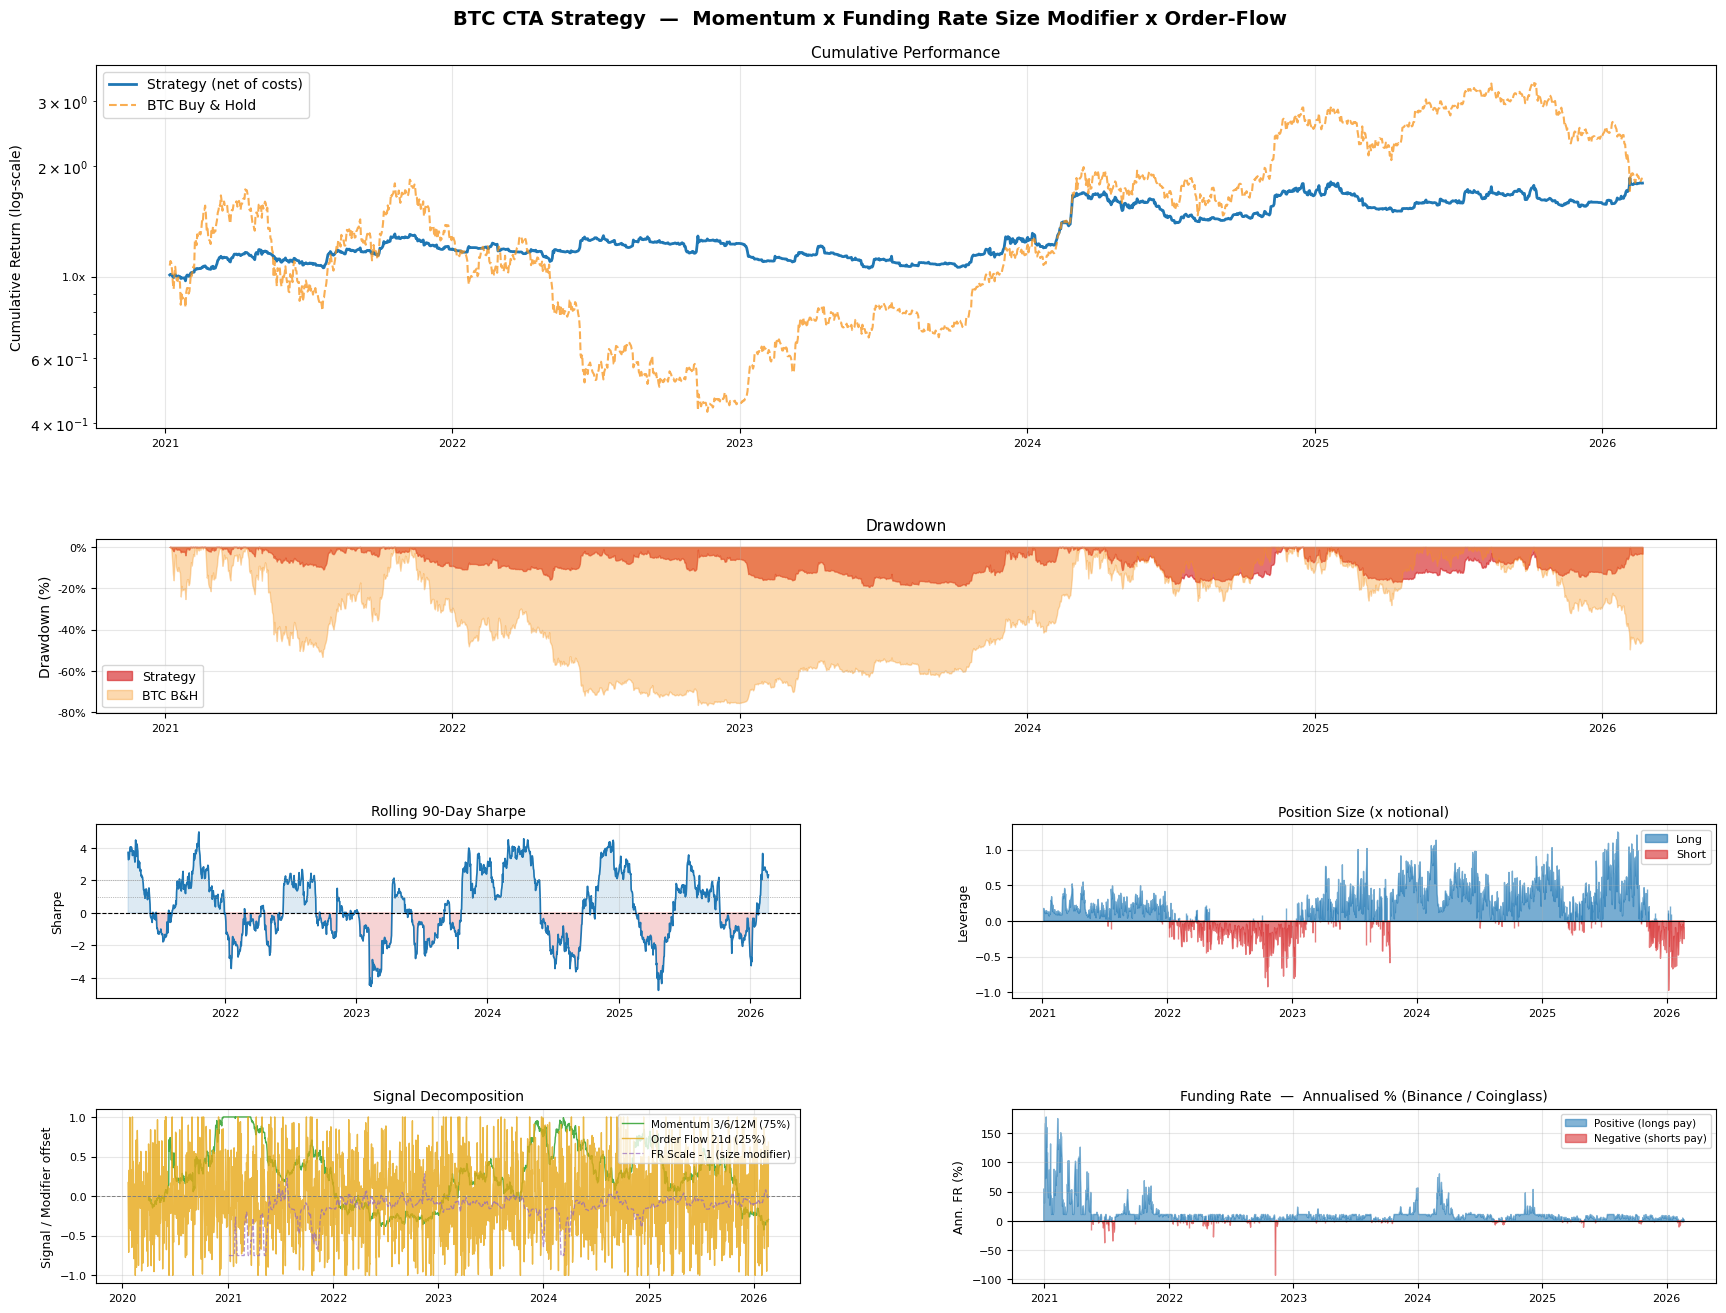

Chart saved → btc_cta_result.png


In [21]:
cum_s   = (1 + net_ret).cumprod()
cum_b   = (1 + btc_ret).cumprod()
dd_s    = (cum_s - cum_s.cummax()) / cum_s.cummax()
dd_b    = (cum_b - cum_b.cummax()) / cum_b.cummax()
roll_sh = net_ret.rolling(90).apply(
    lambda x: x.mean() / x.std() * np.sqrt(ANN) if x.std() > 0 else 0, raw=True)

BLUE, ORANGE, RED = '#1f77b4', '#F7931A', '#d62728'

fig = plt.figure(figsize=(18, 14))
fig.suptitle(
    'BTC CTA Strategy  —  Momentum x Funding Rate Size Modifier x Order-Flow',
    fontsize=14, fontweight='bold', y=0.98)
gs = gridspec.GridSpec(
    4, 2, figure=fig,
    height_ratios=[2.5, 1.2, 1.2, 1.2],
    hspace=0.50, wspace=0.30,
    left=0.07, right=0.97, top=0.94, bottom=0.07)

# ── Panel 1: Cumulative returns ───────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(cum_s.index, cum_s.values, color=BLUE,   lw=2.0, label='Strategy (net of costs)')
ax1.plot(cum_b.index, cum_b.values, color=ORANGE, lw=1.5, ls='--', alpha=0.75,
         label='BTC Buy & Hold')
ax1.set_yscale('log')
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.1f}x'))
ax1.set_ylabel('Cumulative Return (log-scale)', fontsize=10)
ax1.legend(fontsize=10, loc='upper left')
ax1.grid(alpha=0.3)
ax1.set_title('Cumulative Performance', fontsize=11)

# ── Panel 2: Drawdown ─────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, :])
ax2.fill_between(dd_s.index, dd_s.values * 100, 0,
                 color=RED,    alpha=0.65, label='Strategy')
ax2.fill_between(dd_b.index, dd_b.values * 100, 0,
                 color=ORANGE, alpha=0.35, label='BTC B&H')
ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax2.set_ylabel('Drawdown (%)', fontsize=10)
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)
ax2.set_title('Drawdown', fontsize=11)

# ── Panel 3: Rolling 90-Day Sharpe ───────────────────────────────────────────
ax3 = fig.add_subplot(gs[2, 0])
ax3.plot(roll_sh.index, roll_sh.values, color=BLUE, lw=1.2)
ax3.fill_between(roll_sh.index, roll_sh.values, 0,
                 where=roll_sh > 0, color=BLUE, alpha=0.15)
ax3.fill_between(roll_sh.index, roll_sh.values, 0,
                 where=roll_sh < 0, color=RED,  alpha=0.20)
ax3.axhline(0, color='black', lw=0.8, ls='--')
ax3.axhline(1, color='gray',  lw=0.5, ls=':')
ax3.axhline(2, color='gray',  lw=0.5, ls=':')
ax3.set_title('Rolling 90-Day Sharpe', fontsize=10)
ax3.set_ylabel('Sharpe', fontsize=9)
ax3.grid(alpha=0.3)

# ── Panel 4: Position ─────────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[2, 1])
ax4.fill_between(position.index, position.values, 0,
                 where=position >= 0, color=BLUE, alpha=0.60, label='Long')
ax4.fill_between(position.index, position.values, 0,
                 where=position < 0,  color=RED,  alpha=0.60, label='Short')
ax4.axhline(0, color='black', lw=0.8)
ax4.set_title('Position Size (x notional)', fontsize=10)
ax4.set_ylabel('Leverage', fontsize=9)
ax4.legend(fontsize=8)
ax4.grid(alpha=0.3)

# ── Panel 5: Signal Decomposition ─────────────────────────────────────────────
ax5 = fig.add_subplot(gs[3, 0])
ax5.plot(mom.index, mom.values, color='#2ca02c', lw=1.0, alpha=0.85,
         label='Momentum 3/6/12M (75%)')
ax5.plot(ofi.index, ofi.values, color='#e6a817', lw=1.0, alpha=0.80,
         label='Order Flow 21d (25%)')
ax5.plot(fr_sc.index, fr_sc.values - 1.0, color='#9467bd', lw=0.9, alpha=0.70,
         ls='--', label='FR Scale - 1 (size modifier)')
ax5.axhline(0, color='gray', lw=0.7, ls='--')
ax5.set_title('Signal Decomposition', fontsize=10)
ax5.set_ylabel('Signal / Modifier offset', fontsize=9)
ax5.legend(fontsize=7.5, ncol=1, loc='upper right')
ax5.grid(alpha=0.3)

# ── Panel 6: Funding Rate History (alternative data) ─────────────────────────
ax6 = fig.add_subplot(gs[3, 1])
ax6.fill_between(fr_daily.index, fr_daily.values * 100, 0,
                 where=fr_daily >= 0, color=BLUE, alpha=0.55,
                 label='Positive (longs pay)')
ax6.fill_between(fr_daily.index, fr_daily.values * 100, 0,
                 where=fr_daily < 0,  color=RED,  alpha=0.55,
                 label='Negative (shorts pay)')
ax6.axhline(0, color='black', lw=0.8)
ax6.set_title('Funding Rate  —  Annualised % (Binance / Coinglass)', fontsize=10)
ax6.set_ylabel('Ann. FR (%)', fontsize=9)
ax6.legend(fontsize=7.5)
ax6.grid(alpha=0.3)

for ax in [ax1, ax2, ax3, ax4, ax5, ax6]:
    ax.tick_params(labelsize=8)

# Relative path — saves next to this notebook
OUT = 'btc_cta_result.png'
plt.savefig(OUT, dpi=150, bbox_inches='tight')
plt.show()
print(f'Chart saved → {OUT}')


## 5 · Discussion

### Does the result match expectations?

| Regime | BTC return | Expected strategy behaviour | Why |
|--------|-----------|---------------------------|-----|
| **2021 bull run** (Q1–Q4) | +~300% | Long, possibly reduced size mid-year | Momentum long; funding elevated mid-year → FR scale cuts size |
| **2022 bear market** | -~75% | Flip short after sufficient lag | 3M/6M momentum turns negative by Q1–Q2 2022; funding goes negative → FR scale *relaxes* short |
| **2023 recovery** | +~150% | Flip long as trend establishes | Long-horizon momentum gradually turns positive H2 2023 |
| **2024 new ATH** | +~120% | Fully long | Strong momentum signal; funding moderate → minimal size reduction |

### Key design choices and trade-offs

- **Why 3M/6M/12M lookbacks?** Shorter windows (21d) pick up too much mean-reversion noise in crypto. The 3–12 month range captures genuine macro regime shifts (adoption cycles, liquidity cycles).
- **Why funding as size modifier, not direction?** A contrarian funding signal fights sustained bull trends for months. Using it to *scale* exposure (reduce size when longs are crowded) preserves trend-following character while managing crowding risk.
- **Why 60% target vol?** BTC realised vol is ~48% p.a. With a 20% equity-style target, the vol scalar compresses positions to ~0.4× signal, resulting in near-zero average exposure. 60% keeps positions meaningful while still normalising across high/low vol regimes.
- **No in-sample parameter optimisation:** Lookbacks and weights are selected from first principles / academic precedent (Moskowitz et al. 2012 for TSMOM; crypto funding literature for FR signals), not fitted to this specific dataset.

### Limitations
- Single-asset — no diversification across crypto or other markets.
- Long-horizon momentum introduces lag: the strategy will be late to flip at trend inflection points.
- Real execution costs (market impact, funding payments on the short side) can exceed 5 bps for large notionals.
- The period 2021–2026 contains one full cycle; results should be validated out-of-sample on an earlier period if data were available.